<a href="https://colab.research.google.com/github/Ak-Space51/ml-astronomy/blob/main/week4_lens_clip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 4: CLIP Zero-Shot Lens Hunter (Solution)

**Goal:** Use a frozen, pretrained **CLIP** model to rank Euclid cutouts by how lens-like they look - no training. Then evaluate the ranking the way a real survey would: precision, recall, and ROC, not accuracy.

This is the reference solution. Each cell mirrors the starter, with the code filled in and a short note on *why*. Try the starter yourself before reading this. **Use a GPU runtime.**

## Step 0 - Install libraries and pick a device

Colab ships PyTorch and matplotlib, but not Hugging Face `datasets`/`transformers`. Install them, then set the portable device string.

In [1]:
# Run once per Colab session. Quiet to keep the log short.
!pip install -q datasets transformers

In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# The portable pattern: use the GPU if Colab gave us one, else CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 - Load the Euclid strong-lens dataset

We use the `classification` config of [`mwalmsley/euclid_strong_lens_expert_judges`](https://huggingface.co/datasets/mwalmsley/euclid_strong_lens_expert_judges). Each example has an `image`, a `label` (`0` = not a grade-A/B lens, `1` = grade-A/B lens), and an `id_str`.

In [4]:
from datasets import load_dataset

# Official train/test splits come with the dataset - no manual splitting needed.
ds_train = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='train')
ds_test  = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='test')
print(ds_train)
print(ds_test)

README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 5876
})
Dataset({
    features: ['image', 'label', 'id_str'],
    num_rows: 1476
})


## Step 2 - First analysis cell: class balance

Print train/test sizes and the count of each label. **Lenses are rare** - say the imbalance out loud, because it decides every metric you'll use later (see [`04`](../04-zero-shot-lens-finding.md)). A model that predicts 'not a lens' for everything would score high *accuracy* and find *zero* lenses.

In [5]:
# Knowing the positive fraction is the single most important number this week:
# it tells us accuracy will be misleading and we must use precision/recall.
y_train = np.array(ds_train['label'])
y_test = np.array(ds_test['label'])
print('train:', len(y_train), 'test:', len(y_test))
print('train label counts:', np.bincount(y_train))
print('test  label counts:', np.bincount(y_test))
print('test positive (lens) fraction:', round(float(y_test.mean()), 4))

train: 5876 test: 1476
train label counts: [5482  394]
test  label counts: [1372  104]
test positive (lens) fraction: 0.0705


## Step 3 - Look at the data

Plot a small grid of example **lenses** (label 1) and **non-lenses** (label 0). Knowing what you're hunting makes your prompts and your error analysis far better. (See [`02-strong-lens-morphologies.md`](../02-strong-lens-morphologies.md).)

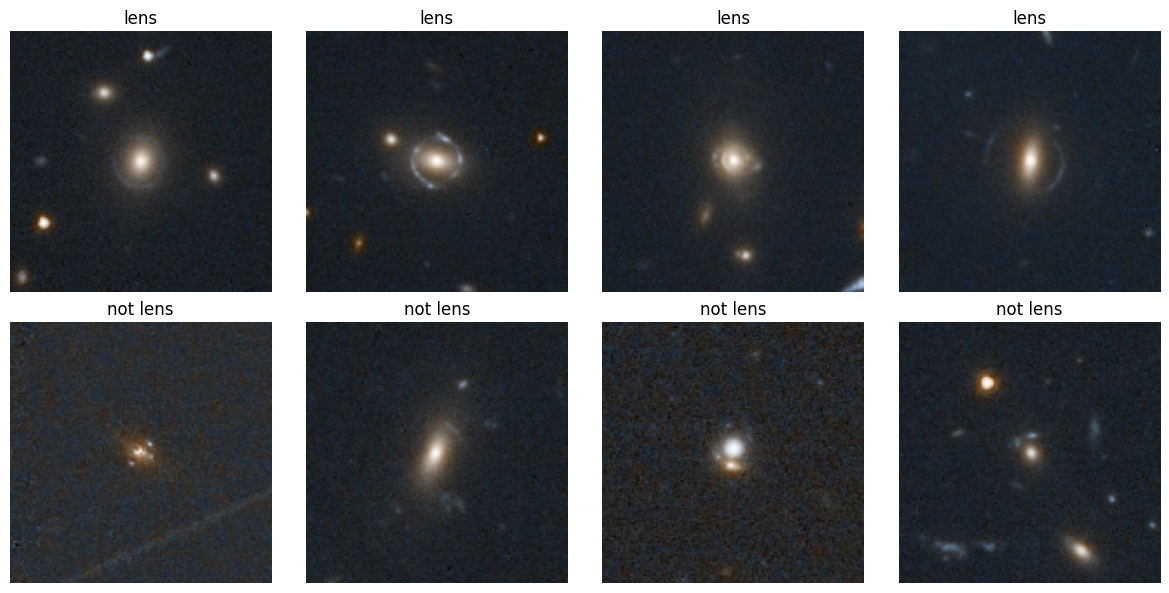

In [6]:
# Eyeball the two classes so your prompts (and your error reading) are grounded.
pos_idx = [i for i, y in enumerate(ds_test['label']) if y == 1][:4]
neg_idx = [i for i, y in enumerate(ds_test['label']) if y == 0][:4]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes[0], pos_idx):
    ax.imshow(ds_test[i]['image']); ax.set_title('lens'); ax.axis('off')
for ax, i in zip(axes[1], neg_idx):
    ax.imshow(ds_test[i]['image']); ax.set_title('not lens'); ax.axis('off')
plt.tight_layout(); plt.show()

## Step 4 - Load CLIP

Load `openai/clip-vit-base-patch32` and its matching `CLIPProcessor` (the processor does CLIP's own resize + normalisation - always use it). Move the model to the device and put it in `eval()` mode; we never train it.

In [7]:
from transformers import CLIPModel, CLIPProcessor

# Base patch32 is small enough for a T4 and the standard zero-shot baseline.
model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device).eval()
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
print('CLIP loaded on', device)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded on cuda


In [14]:
lens_prompts = [
    'a strong gravitational lens with an Einstein ring',
    'a gravitational lens arc next to a galaxy',
    'multiple images of a background source due to gravitational lensing']
nonlens_prompts = [
    'a normal galaxy without gravitational lensing',
    'a spiral galaxy with curved arms but no gravitational lens arc',
    'a smooth elliptical galaxy with no lensing features']
all_prompts = lens_prompts + nonlens_prompts
n_lens = len(lens_prompts)

text_inputs = processor(text=all_prompts, return_tensors='pt', padding=True).to(device)
with torch.no_grad():
    # The get_text_features method is expected to return a tensor, but if it returns a
    # BaseModelOutputWithPooling object (as indicated by the error), we need to extract
    # the actual embeddings from its 'pooler_output' attribute.
    text_emb_output = model.get_text_features(**text_inputs)
    if hasattr(text_emb_output, 'pooler_output'):
        text_emb = text_emb_output.pooler_output
    else:
        text_emb = text_emb_output # Assume it's already the tensor if no pooler_output

# Normalise so a dot product becomes cosine similarity.
text_emb = F.normalize(text_emb, dim=-1)
print('text embeddings:', text_emb.shape)

text embeddings: torch.Size([6, 512])


## Step 5 - Build a prompt bank and embed it

Write at least **two lens** prompts and **two non-lens** prompts (start from the bank in [`04`](../04-zero-shot-lens-finding.md)). Notice the non-lens prompts deliberately name the decoys (spiral arms!). Embed the prompts once and L2-normalise them.

## Step 6 - Embed all test images (in batches)

Loop over the test set in **chunks of 32-64** under `torch.no_grad()`, run the CLIP image encoder, and L2-normalise. Embedding in batches keeps you off the T4's memory limit. Collect one big `(N, D)` tensor of normalised image embeddings.

In [16]:
images = [im.convert('RGB') for im in ds_test['image']]
img_embs = []
batch = 64
for start in range(0, len(images), batch):
    chunk = images[start:start + batch]
    inputs = processor(images=chunk, return_tensors='pt').to(device)
    with torch.no_grad():
        emb_output = model.get_image_features(**inputs)
        # Similar to text embeddings, if get_image_features returns a
        # BaseModelOutputWithPooling object, extract the actual embeddings.
        if hasattr(emb_output, 'pooler_output'):
            emb = emb_output.pooler_output
        else:
            emb = emb_output # Assume it's already the tensor if no pooler_output
    img_embs.append(F.normalize(emb, dim=-1).cpu())
img_emb = torch.cat(img_embs)
print('image embeddings:', img_emb.shape)

image embeddings: torch.Size([1476, 512])


## Step 7 - Score each image

With normalised vectors, cosine similarity is just a matrix product. Compute `sims = img_emb @ text_emb.T` (shape `(N, num_prompts)`), then:

`score = mean(similarity to lens prompts) - mean(similarity to non-lens prompts)`

A positive score means 'more lens-like'. This single number is your detector's output.

In [17]:
# Difference of group means: how much more lens-like than non-lens-like is this cutout?
sims = img_emb @ text_emb.cpu().T            # (N, num_prompts), all cosine sims
lens_sim = sims[:, :n_lens].mean(dim=1)
nonlens_sim = sims[:, n_lens:].mean(dim=1)
scores = (lens_sim - nonlens_sim).numpy()
print('score range:', round(float(scores.min()), 4), 'to', round(float(scores.max()), 4))

score range: -0.0313 to 0.0244


## Step 8 - Evaluate: ROC-AUC + ROC/PR curves

Report **ROC-AUC** (threshold-free ranking quality: 1.0 perfect, 0.5 random), then plot the ROC and precision-recall curves. For an **imbalanced** problem like ours the PR curve is often more honest. Finally pick a threshold and justify it - real surveys favour **precision** because each candidate costs human follow-up time. (See [`04`](../04-zero-shot-lens-finding.md).)

ROC-AUC: 0.4845


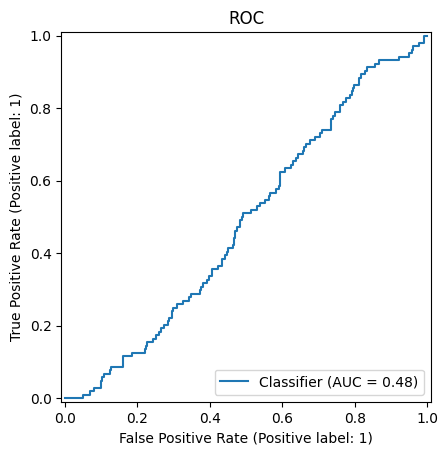

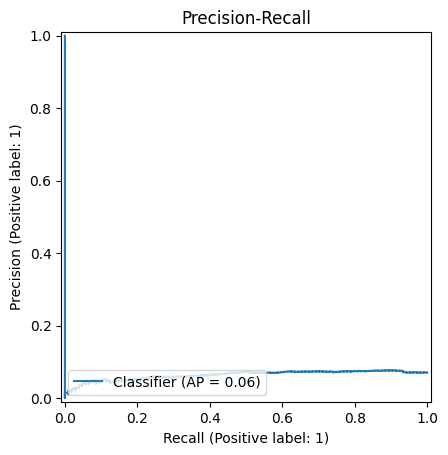

threshold t = 0.0044
              precision    recall  f1-score   support

    not lens       0.93      0.90      0.91      1372
        lens       0.04      0.06      0.05       104

    accuracy                           0.84      1476
   macro avg       0.48      0.48      0.48      1476
weighted avg       0.86      0.84      0.85      1476



In [18]:
from sklearn.metrics import (roc_auc_score, RocCurveDisplay,
                             PrecisionRecallDisplay, classification_report)

# ROC-AUC is threshold-free: it asks 'does the score rank lenses above non-lenses?'
print('ROC-AUC:', round(roc_auc_score(y_test, scores), 4))
RocCurveDisplay.from_predictions(y_test, scores); plt.title('ROC'); plt.show()
PrecisionRecallDisplay.from_predictions(y_test, scores); plt.title('Precision-Recall'); plt.show()

# Pick a threshold. Here we favour precision (survey-style): take the 90th percentile
# of scores so only the most lens-like ~10% are flagged. Tune this from the PR curve.
t = np.quantile(scores, 0.90)
preds = (scores >= t).astype(int)
print(f'threshold t = {t:.4f}')
print(classification_report(y_test, preds, target_names=['not lens', 'lens']))

## Step 9 - Error gallery

Sort by score and display: the **top true positives** (highest-scoring real lenses), the **worst false positives** (highest-scoring non-lenses - expect spirals/ring galaxies), and the **worst false negatives** (real lenses scored low). Title each panel with its score and true label. This gallery is where the science lives.

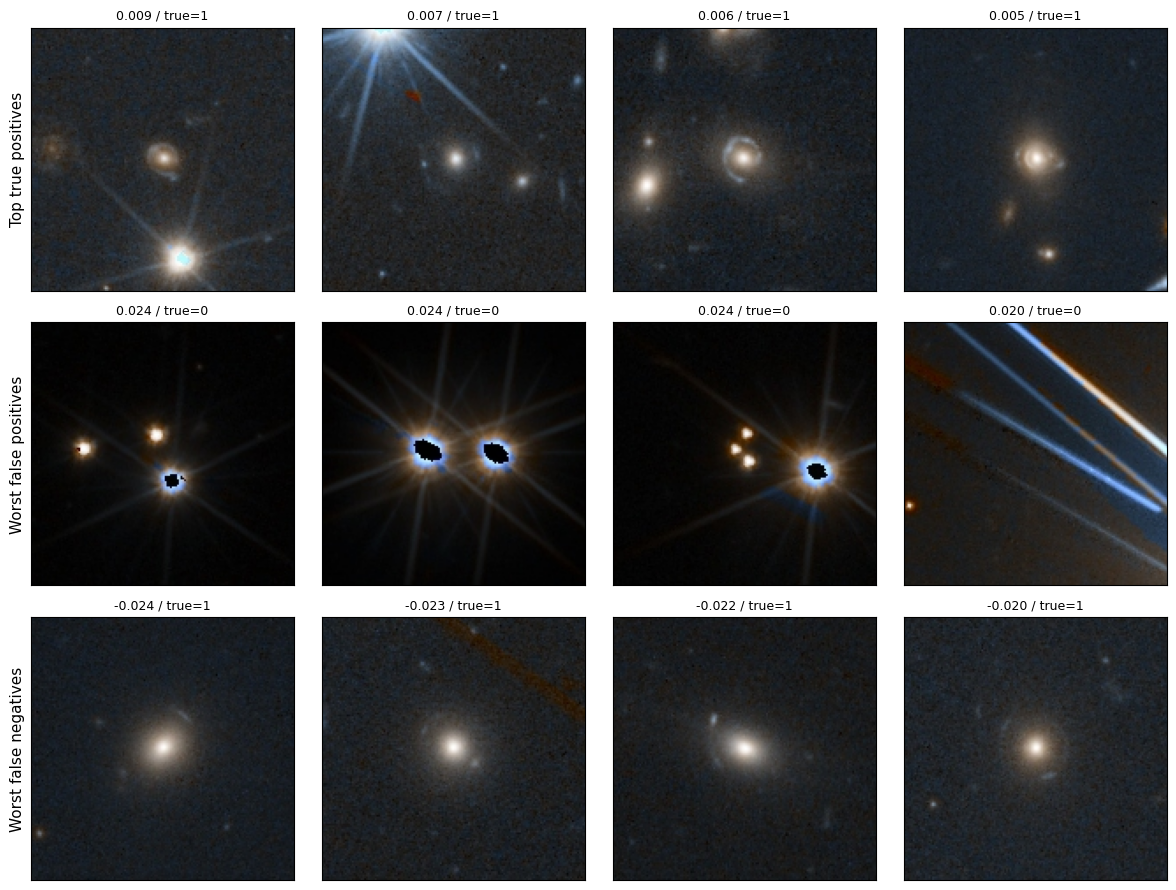

In [20]:
y = np.array(y_test)
order = np.argsort(-scores)                   # highest score first
top_tp = [i for i in order if y[i] == 1][:4]          # real lenses ranked high (good)
worst_fp = [i for i in order if y[i] == 0][:4]        # non-lenses ranked high (false alarms)
worst_fn = [i for i in order[::-1] if y[i] == 1][:4]  # real lenses ranked low (missed)

rows = [('Top true positives', top_tp),
        ('Worst false positives', worst_fp),
        ('Worst false negatives', worst_fn)]
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for (title, idxs), row in zip(rows, axes):
    row[0].set_ylabel(title, fontsize=11)
    for ax, i in zip(row, idxs):
        ax.imshow(ds_test[int(i)]['image']) # Cast numpy.int64 to int for indexing
        ax.set_title(f'{scores[i]:.3f} / true={y[i]}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Reflection *(example answers - write your own)*

1. Zero-shot CLIP typically lands well above chance (ROC-AUC ~0.5) but well below a trained detector - impressive given it saw **zero** labelled lenses, yet far from production quality. The gap is the value of task-specific training and domain-matched data.
2. The worst false positives are usually face-on **spirals** or **ring galaxies**: CLIP correctly sees 'curved bright structure offset from a centre', which is genuinely lens-like in appearance. As [`02`](../02-strong-lens-morphologies.md) explains, the tell-tale is whether the curve wraps a *separate* foreground galaxy - something CLIP can't reason about.
3. A 'say no to everything' model scores accuracy equal to the non-lens fraction (often >90%) while finding zero lenses - which is why we report **precision/recall** and **ROC-AUC**, metrics that reward actually catching the rare positives.